## Import packages and define some functions

In [1]:
import matplotlib.pyplot as plt
import matplotlib as matplotlib
import numpy as np
import pandas as pd
import seaborn as sns
import scipy.stats as stats
import scipy as scipy

from collections import Counter
import os

matplotlib.__version__, np.__version__, pd.__version__, sns.__version__, scipy.__version__

('3.9.2', '1.26.4', '2.2.2', '0.13.2', '1.13.1')

In [2]:

chr_ID_to_genbank = {'Ca22chr1A_C_albicans_SC5314':'NC_032089.1',
                     'Ca22chr2A_C_albicans_SC5314':'NC_032090.1',
                     'Ca22chr3A_C_albicans_SC5314':'NC_032091.1',
                     'Ca22chr4A_C_albicans_SC5314':'NC_032092.1',
                     'Ca22chr5A_C_albicans_SC5314':'NC_032093.1',
                     'Ca22chr6A_C_albicans_SC5314':'NC_032094.1',
                     'Ca22chr7A_C_albicans_SC5314':'NC_032095.1',
                     'Ca22chrRA_C_albicans_SC5314':'NC_032096.1'}

genbank_to_chr_no = {'NC_032089.1':'Chr1',
                     'NC_032090.1':'Chr2',
                     'NC_032091.1':'Chr3',
                     'NC_032092.1':'Chr4',
                     'NC_032093.1':'Chr5',
                     'NC_032094.1':'Chr6',
                     'NC_032095.1':'Chr7',
                     'NC_032096.1':'ChrR',
                     'genome':'genome'}

In [3]:
cov_file_list = os.listdir('./genome_cov/')
cov_file_list
# list of coverage histograms generated by Bedtools genomecov

['.ipynb_checkpoints',
 'frs_1_align.cov.txt',
 'frs_242_align.cov.txt',
 'frs_246_align.cov.txt']

In [4]:
median_cov_dict_of_dict = {}
# dict of dict container for median coverage values

for file in cov_file_list:
    if 'ipy' not in file:
        hist_file = pd.read_csv('./genome_cov/'+file, sep='\t', names=['chr_ID', 'coverage', 'n_obs', 'chr_len', 'density'])
        hist_file['chr_name'] = hist_file['chr_ID'].map(genbank_to_chr_no)
        # loop through files and get coverage info
    
        median_dict = {}
        # container for rows
    
        for chrom in hist_file['chr_name'].unique():
            sub_df = hist_file[hist_file['chr_name']==chrom]
            # loop through chromosomes and slice df
        
            raw_cov_list = []
        
            for row in list(sub_df.index):
                cov = sub_df.loc[row, 'coverage']
                n_obs = sub_df.loc[row, 'n_obs']
                raw_cov_list += [cov]*n_obs
                # convert format to generate full distributions
        
            median_dict[chrom] = np.median(raw_cov_list)
            # compute median
        
            raw_cov_list = []
        median_cov_dict_of_dict[file] = median_dict
        # add column info to dict of dicts



In [5]:
median_cov_df = pd.DataFrame.from_dict(median_cov_dict_of_dict).T
# make df

In [6]:
for col in ['Chr1', 'Chr2', 'Chr3', 'Chr4', 'Chr5', 'Chr6', 'Chr7', 'ChrR']:
    median_cov_df[(col+'_rel')] = median_cov_df[col]/median_cov_df['genome']
# add relative coverage
median_cov_df

,Chr1,Chr2,Chr3,Chr4,Chr5,Chr6,Chr7,ChrR,genome,Chr1_rel,Chr2_rel,Chr3_rel,Chr4_rel,Chr5_rel,Chr6_rel,Chr7_rel,ChrR_rel
frs_1_align.cov.txt,84.0,83.0,83.0,82.0,80.0,79.0,77.0,86.0,83.0,1.012048,1.0,1.0,0.987952,0.963855,0.951807,0.927711,1.036145
frs_242_align.cov.txt,71.0,72.0,72.0,71.0,70.0,69.0,69.0,77.0,72.0,0.986111,1.0,1.0,0.986111,0.972222,0.958333,0.958333,1.069444
frs_246_align.cov.txt,71.0,71.0,71.0,70.0,70.0,70.0,70.0,72.0,71.0,1.000000,1.0,1.0,0.985915,0.985915,0.985915,0.985915,1.014085


In [7]:
median_cov_df[['Chr1', 'Chr1_rel', 
               'Chr2', 'Chr2_rel',
               'Chr3', 'Chr3_rel',
               'Chr4', 'Chr4_rel',
               'Chr5', 'Chr5_rel',
               'Chr6', 'Chr6_rel',
               'Chr7', 'Chr7_rel',
               'ChrR', 'ChrR_rel',
               'genome']].to_csv('./genome_cov_table.csv')
# export table

In [8]:
chr_color_dict = sns.color_palette('husl',8)
chr_color_dict

[(0.9677975592919913, 0.44127456009157356, 0.5358103155058701),
 (0.8087954113106306, 0.5634700050056693, 0.19502642696727285),
 (0.5920891529639701, 0.6418467016378244, 0.1935069134991043),
 (0.19783576093349015, 0.6955516966063037, 0.3995301037444499),
 (0.21044753832183283, 0.6773105080456748, 0.6433941168468681),
 (0.22335772267769388, 0.6565792317435265, 0.8171355503265633),
 (0.6423044349219739, 0.5497680051256467, 0.9582651433656727),
 (0.96038885399407, 0.3814317878772117, 0.8683117650835491)]

(array([0.   , 0.005, 0.01 , 0.015, 0.02 , 0.025]),
 [Text(0, 0.0, '0.000'),
  Text(0, 0.005, '0.005'),
  Text(0, 0.01, '0.010'),
  Text(0, 0.015, '0.015'),
  Text(0, 0.02, '0.020'),
  Text(0, 0.025, '0.025')])

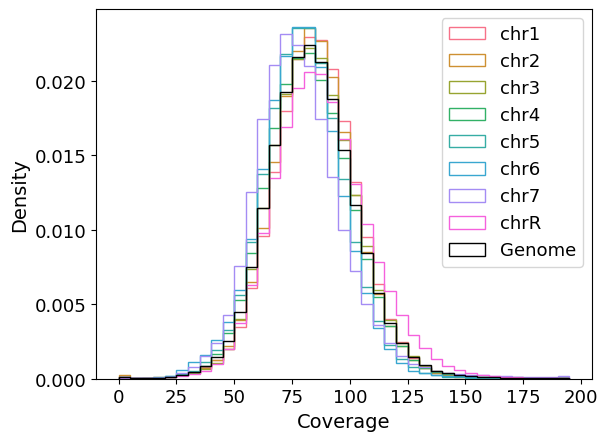

In [10]:
################# FRS1

hist_file = pd.read_csv('./genome_cov/frs_1_align.cov.txt', sep='\t', names=['chr_ID', 'coverage', 'n_obs', 'chr_len', 'density'])
hist_file['chr_name'] = hist_file['chr_ID'].map(genbank_to_chr_no)
# loop through files and get coverage info

x=0
for chrom in hist_file['chr_name'].unique():
    sub_df = hist_file[hist_file['chr_name']==chrom]
    # loop through chromosomes and slice df

    raw_cov_list = []

    for row in list(sub_df.index):
        cov = sub_df.loc[row, 'coverage']
        n_obs = sub_df.loc[row, 'n_obs']
        raw_cov_list += [cov]*n_obs
        # convert format to generate full distributions
    if x < 8:
        plt.hist(raw_cov_list, bins = range(0,200,5), histtype='step', density =True, color=chr_color_dict[x])
    else:
        plt.hist(raw_cov_list, bins = range(0,200,5), histtype='step', density =True, color='k')
    x+=1

plt.legend(['chr1', 'chr2', 'chr3', 'chr4', 'chr5', 'chr6', 'chr7', 'chrR', 'Genome'], fontsize=13)
plt.xlabel('Coverage', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)

(array([0.   , 0.005, 0.01 , 0.015, 0.02 , 0.025, 0.03 ]),
 [Text(0, 0.0, '0.000'),
  Text(0, 0.005, '0.005'),
  Text(0, 0.01, '0.010'),
  Text(0, 0.015, '0.015'),
  Text(0, 0.02, '0.020'),
  Text(0, 0.025, '0.025'),
  Text(0, 0.03, '0.030')])

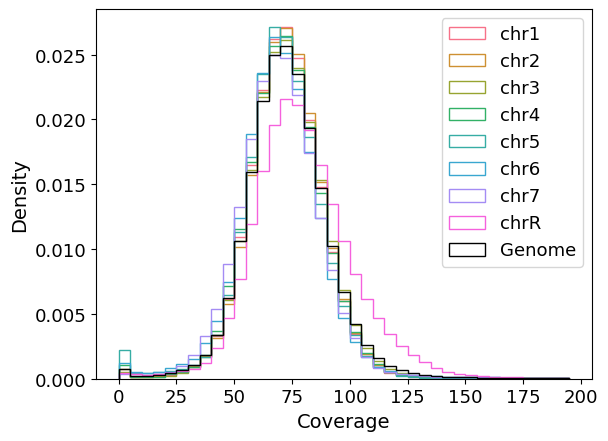

In [11]:
################# FRS242

hist_file = pd.read_csv('./genome_cov/frs_242_align.cov.txt', sep='\t', names=['chr_ID', 'coverage', 'n_obs', 'chr_len', 'density'])
hist_file['chr_name'] = hist_file['chr_ID'].map(genbank_to_chr_no)
# loop through files and get coverage info

x=0
for chrom in hist_file['chr_name'].unique():
    sub_df = hist_file[hist_file['chr_name']==chrom]
    # loop through chromosomes and slice df

    raw_cov_list = []

    for row in list(sub_df.index):
        cov = sub_df.loc[row, 'coverage']
        n_obs = sub_df.loc[row, 'n_obs']
        raw_cov_list += [cov]*n_obs
        # convert format to generate full distributions
    if x < 8:
        plt.hist(raw_cov_list, bins = range(0,200,5), histtype='step', density =True, color=chr_color_dict[x])
    else:
        plt.hist(raw_cov_list, bins = range(0,200,5), histtype='step', density =True, color='k')
    x+=1

plt.legend(['chr1', 'chr2', 'chr3', 'chr4', 'chr5', 'chr6', 'chr7', 'chrR', 'Genome'], fontsize=13)
plt.xlabel('Coverage', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)

(array([0.   , 0.005, 0.01 , 0.015, 0.02 , 0.025, 0.03 ]),
 [Text(0, 0.0, '0.000'),
  Text(0, 0.005, '0.005'),
  Text(0, 0.01, '0.010'),
  Text(0, 0.015, '0.015'),
  Text(0, 0.02, '0.020'),
  Text(0, 0.025, '0.025'),
  Text(0, 0.03, '0.030')])

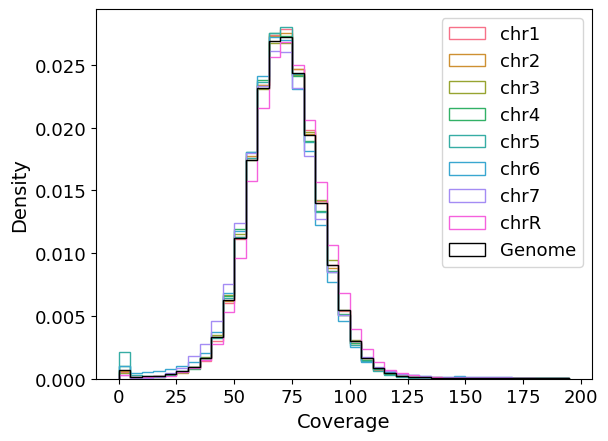

In [12]:
################# FRS246

hist_file = pd.read_csv('./genome_cov/frs_246_align.cov.txt', sep='\t', names=['chr_ID', 'coverage', 'n_obs', 'chr_len', 'density'])
hist_file['chr_name'] = hist_file['chr_ID'].map(genbank_to_chr_no)
# loop through files and get coverage info

x=0
for chrom in hist_file['chr_name'].unique():
    sub_df = hist_file[hist_file['chr_name']==chrom]
    # loop through chromosomes and slice df

    raw_cov_list = []

    for row in list(sub_df.index):
        cov = sub_df.loc[row, 'coverage']
        n_obs = sub_df.loc[row, 'n_obs']
        raw_cov_list += [cov]*n_obs
        # convert format to generate full distributions
    if x < 8:
        plt.hist(raw_cov_list, bins = range(0,200,5), histtype='step', density =True, color=chr_color_dict[x])
    else:
        plt.hist(raw_cov_list, bins = range(0,200,5), histtype='step', density =True, color='k')
    x+=1

plt.legend(['chr1', 'chr2', 'chr3', 'chr4', 'chr5', 'chr6', 'chr7', 'chrR', 'Genome'], fontsize=13)
plt.xlabel('Coverage', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)

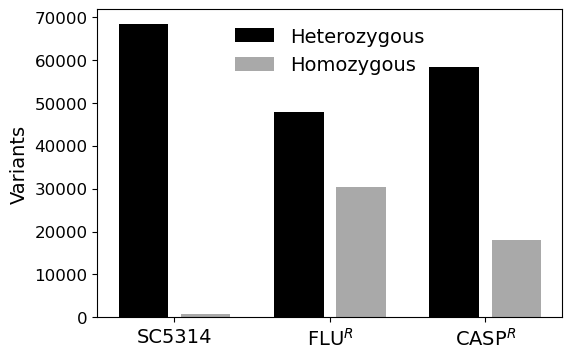

In [76]:
plt.figure(figsize=(6,4))

plt.bar(x=[0], height=[68389], color=['k'])
plt.bar(x=[1], height=[791], color=['darkgrey'])

plt.bar(x=[2.5], height=[47769], color=['k'])
plt.bar(x=[3.5], height=[30367], color=['darkgrey'])


plt.bar(x=[5], height=[58371], color=['k'])
plt.bar(x=[6], height=[17980], color=['darkgrey'])



plt.legend(['Heterozygous', 'Homozygous'], loc='upper center', fontsize=14, frameon=False)


plt.xticks([0.5,3,5.5], ['SC5314', 'FLU$^{R}$', 'CASP$^{R}$'], fontsize=14)
plt.yticks(fontsize=12)
plt.ylabel('Variants', fontsize=14)

plt.savefig('./variant_calls.svg', format='svg', dpi=300)

In [17]:
het_sites_df = pd.read_csv('./C_albicans_SC5314_haplotype_variations.tab', sep='\t')
het_sites_df

,Hap A Chromosome,Hap A Upstream Coord,Hap A Downstream Coord,Hap B Chromosome,Hap B Upstream Coord,Hap B Downstream Coord,Change Type,Hap A Seq,Hap B Seq,Affected Features
0,Ca22chr1A_C_albicans_SC5314,647,649,Ca22chr1B_C_albicans_SC5314,647,649,1 nt ambig,AST,AST,intergenic
1,Ca22chr1A_C_albicans_SC5314,1173,1175,Ca22chr1B_C_albicans_SC5314,1173,1175,1 nt ambig,TYT,TYT,intergenic
2,Ca22chr1A_C_albicans_SC5314,1180,1182,Ca22chr1B_C_albicans_SC5314,1180,1182,1 nt ambig,CRC,CRC,intergenic
3,Ca22chr1A_C_albicans_SC5314,1559,1561,Ca22chr1B_C_albicans_SC5314,1559,1561,1 nt ambig,GWC,GWC,intergenic
4,Ca22chr1A_C_albicans_SC5314,1784,1786,Ca22chr1B_C_albicans_SC5314,1784,1786,1 nt ambig,CMA,CMA,intergenic
...,...,...,...,...,...,...,...,...,...,...
64553,Ca22chrRA_C_albicans_SC5314,2205134,2205136,Ca22chrRB_C_albicans_SC5314,2204594,2204596,1 nt ambig,GKG,GKG,intergenic
64554,Ca22chrRA_C_albicans_SC5314,2265036,2265038,Ca22chrRB_C_albicans_SC5314,2264496,2264498,1 nt subs,CAA,CGA,CR_10680W/RPO21
64555,Ca22chrRA_C_albicans_SC5314,2265078,2265080,Ca22chrRB_C_albicans_SC5314,2264538,2264540,1 nt subs,CGA,CAA,CR_10680W/RPO21
64556,Ca22chrRA_C_albicans_SC5314,2285820,2285822,Ca22chrRB_C_albicans_SC5314,2285280,2285282,1 nt subs,CCT,CTT,CR_10860C/CTA26


In [18]:
het_sites_df['Hap_A_start_pos'] = het_sites_df['Hap A Upstream Coord']+1
het_sites_df

,Hap A Chromosome,Hap A Upstream Coord,Hap A Downstream Coord,Hap B Chromosome,Hap B Upstream Coord,Hap B Downstream Coord,Change Type,Hap A Seq,Hap B Seq,Affected Features,Hap_A_start_pos
0,Ca22chr1A_C_albicans_SC5314,647,649,Ca22chr1B_C_albicans_SC5314,647,649,1 nt ambig,AST,AST,intergenic,648
1,Ca22chr1A_C_albicans_SC5314,1173,1175,Ca22chr1B_C_albicans_SC5314,1173,1175,1 nt ambig,TYT,TYT,intergenic,1174
2,Ca22chr1A_C_albicans_SC5314,1180,1182,Ca22chr1B_C_albicans_SC5314,1180,1182,1 nt ambig,CRC,CRC,intergenic,1181
3,Ca22chr1A_C_albicans_SC5314,1559,1561,Ca22chr1B_C_albicans_SC5314,1559,1561,1 nt ambig,GWC,GWC,intergenic,1560
4,Ca22chr1A_C_albicans_SC5314,1784,1786,Ca22chr1B_C_albicans_SC5314,1784,1786,1 nt ambig,CMA,CMA,intergenic,1785
...,...,...,...,...,...,...,...,...,...,...,...
64553,Ca22chrRA_C_albicans_SC5314,2205134,2205136,Ca22chrRB_C_albicans_SC5314,2204594,2204596,1 nt ambig,GKG,GKG,intergenic,2205135
64554,Ca22chrRA_C_albicans_SC5314,2265036,2265038,Ca22chrRB_C_albicans_SC5314,2264496,2264498,1 nt subs,CAA,CGA,CR_10680W/RPO21,2265037
64555,Ca22chrRA_C_albicans_SC5314,2265078,2265080,Ca22chrRB_C_albicans_SC5314,2264538,2264540,1 nt subs,CGA,CAA,CR_10680W/RPO21,2265079
64556,Ca22chrRA_C_albicans_SC5314,2285820,2285822,Ca22chrRB_C_albicans_SC5314,2285280,2285282,1 nt subs,CCT,CTT,CR_10860C/CTA26,2285821


In [19]:
genbank_to_chr_ID = {'NC_032089.1':'Ca22chr1A_C_albicans_SC5314',
                     'NC_032090.1':'Ca22chr2A_C_albicans_SC5314',
                     'NC_032091.1':'Ca22chr3A_C_albicans_SC5314',
                     'NC_032092.1':'Ca22chr4A_C_albicans_SC5314',
                     'NC_032093.1':'Ca22chr5A_C_albicans_SC5314',
                     'NC_032094.1':'Ca22chr6A_C_albicans_SC5314',
                     'NC_032095.1':'Ca22chr7A_C_albicans_SC5314',
                     'NC_032096.1':'Ca22chrRA_C_albicans_SC5314'}

In [20]:

def read_bed_intersect(file):
    # example command to generate intersect mapping
    # bedtools intersect -bed -wb -a ./sgRNA_mapping.sorted.bam -b ./vcf/frs_1_hard_filtered.nonbinary.pass.vcf > ./intersect/frs1_intersect.txt

    line_dict_of_dicts = {}
    
    with open(file, 'r') as source:

        index=0

        for line in source:

            line_dict = {}
            
            line = line.split('\t')

            sgRNA_info = line[3].split('_C')
            line_dict['sgRNA'] = sgRNA_info[0].replace('sgRNA_','')
            line_dict['Gene'] = 'C'+sgRNA_info[1]
            line_dict['sgRNA_range'] = (int(line[6]), int(line[7]))
            #print(repr(line))

            SNP_chr = genbank_to_chr_ID[line[0]]
            line_dict['Chr'] = SNP_chr

            SNP_pos = int(line[13])
            line_dict['SNP_pos'] = SNP_pos

            line_dict['Ref'] = line[15]
            line_dict['Alt'] = line[16]

            if len(line[15]) == len(line[16]):
                line_dict['Type'] = 'SNP'
            else:
                line_dict['Type'] = 'Indel'
            

            line_dict['Genotype_call'] = line[-1].split(':')[0]


            

            line_dict_of_dicts[index] = line_dict
            index+=1

    out_df = pd.DataFrame.from_dict(line_dict_of_dicts).T

    return out_df
        

read_bed_intersect('./intersect/frs1_intersect.txt')

,sgRNA,Gene,sgRNA_range,Chr,SNP_pos,Ref,Alt,Type,Genotype_call
0,60,C1_03980W,"(838196, 838219)",Ca22chr1A_C_albicans_SC5314,838214,G,A,SNP,0|1
1,66,C1_05560W,"(1166802, 1166825)",Ca22chr1A_C_albicans_SC5314,1166815,G,A,SNP,0|1
2,68,C1_05560W,"(1166839, 1166862)",Ca22chr1A_C_albicans_SC5314,1166862,C,G,SNP,0|1
3,83,C1_07240W,"(1553461, 1553484)",Ca22chr1A_C_albicans_SC5314,1553473,A,G,SNP,0|1
4,83,C1_07240W,"(1553461, 1553484)",Ca22chr1A_C_albicans_SC5314,1553477,C,T,SNP,0|1
5,91,C1_07910C,"(1725010, 1725033)",Ca22chr1A_C_albicans_SC5314,1725022,T,C,SNP,0|1
6,91,C1_07910C,"(1725010, 1725033)",Ca22chr1A_C_albicans_SC5314,1725023,G,A,SNP,0|1
7,91,C1_07910C,"(1725010, 1725033)",Ca22chr1A_C_albicans_SC5314,1725024,G,A,SNP,0|1
8,90,C1_07910C,"(1725011, 1725034)",Ca22chr1A_C_albicans_SC5314,1725022,T,C,SNP,0|1
9,90,C1_07910C,"(1725011, 1725034)",Ca22chr1A_C_albicans_SC5314,1725023,G,A,SNP,0|1


In [21]:
frs1_intersect_df = read_bed_intersect('./intersect/frs1_intersect.txt')
frs1_intersect_df

,sgRNA,Gene,sgRNA_range,Chr,SNP_pos,Ref,Alt,Type,Genotype_call
0,60,C1_03980W,"(838196, 838219)",Ca22chr1A_C_albicans_SC5314,838214,G,A,SNP,0|1
1,66,C1_05560W,"(1166802, 1166825)",Ca22chr1A_C_albicans_SC5314,1166815,G,A,SNP,0|1
2,68,C1_05560W,"(1166839, 1166862)",Ca22chr1A_C_albicans_SC5314,1166862,C,G,SNP,0|1
3,83,C1_07240W,"(1553461, 1553484)",Ca22chr1A_C_albicans_SC5314,1553473,A,G,SNP,0|1
4,83,C1_07240W,"(1553461, 1553484)",Ca22chr1A_C_albicans_SC5314,1553477,C,T,SNP,0|1
5,91,C1_07910C,"(1725010, 1725033)",Ca22chr1A_C_albicans_SC5314,1725022,T,C,SNP,0|1
6,91,C1_07910C,"(1725010, 1725033)",Ca22chr1A_C_albicans_SC5314,1725023,G,A,SNP,0|1
7,91,C1_07910C,"(1725010, 1725033)",Ca22chr1A_C_albicans_SC5314,1725024,G,A,SNP,0|1
8,90,C1_07910C,"(1725011, 1725034)",Ca22chr1A_C_albicans_SC5314,1725022,T,C,SNP,0|1
9,90,C1_07910C,"(1725011, 1725034)",Ca22chr1A_C_albicans_SC5314,1725023,G,A,SNP,0|1


In [22]:
def map_het_sites(df):

    map_info = {}
    
    for index in list(df.index):

        Chr=df.at[index, 'Chr']
        SNP_pos = df.at[index, 'SNP_pos']
        #print(SNP_pos)

        het_site_slice = het_sites_df[(het_sites_df['Hap A Chromosome']==Chr)&(het_sites_df['Hap_A_start_pos']==SNP_pos)]
        #print(het_site_slice)
        if len(het_site_slice)>=1:
            #print(het_site_slice)
            map_info[index] = 'SC5314'
        else:
            map_info[index] = 'de novo'

    df['map_info'] = pd.Series(map_info)

map_het_sites(frs1_intersect_df)


In [23]:
####### FRS1

In [24]:
frs1_intersect_df
# 495705 not de novo, just bad coords mapping

,sgRNA,Gene,sgRNA_range,Chr,SNP_pos,Ref,Alt,Type,Genotype_call,map_info
0,60,C1_03980W,"(838196, 838219)",Ca22chr1A_C_albicans_SC5314,838214,G,A,SNP,0|1,SC5314
1,66,C1_05560W,"(1166802, 1166825)",Ca22chr1A_C_albicans_SC5314,1166815,G,A,SNP,0|1,de novo
2,68,C1_05560W,"(1166839, 1166862)",Ca22chr1A_C_albicans_SC5314,1166862,C,G,SNP,0|1,SC5314
3,83,C1_07240W,"(1553461, 1553484)",Ca22chr1A_C_albicans_SC5314,1553473,A,G,SNP,0|1,SC5314
4,83,C1_07240W,"(1553461, 1553484)",Ca22chr1A_C_albicans_SC5314,1553477,C,T,SNP,0|1,de novo
5,91,C1_07910C,"(1725010, 1725033)",Ca22chr1A_C_albicans_SC5314,1725022,T,C,SNP,0|1,de novo
6,91,C1_07910C,"(1725010, 1725033)",Ca22chr1A_C_albicans_SC5314,1725023,G,A,SNP,0|1,de novo
7,91,C1_07910C,"(1725010, 1725033)",Ca22chr1A_C_albicans_SC5314,1725024,G,A,SNP,0|1,de novo
8,90,C1_07910C,"(1725011, 1725034)",Ca22chr1A_C_albicans_SC5314,1725022,T,C,SNP,0|1,de novo
9,90,C1_07910C,"(1725011, 1725034)",Ca22chr1A_C_albicans_SC5314,1725023,G,A,SNP,0|1,de novo


In [25]:
dict(frs1_intersect_df['sgRNA'].value_counts())

{'480': 3,
 '91': 3,
 '90': 3,
 '92': 3,
 '485': 3,
 '150': 2,
 '355': 2,
 '298': 2,
 '297': 2,
 '149': 2,
 '306': 2,
 '152': 2,
 '497': 2,
 '83': 2,
 '464': 1,
 '457': 1,
 '459': 1,
 '458': 1,
 '60': 1,
 '473': 1,
 '484': 1,
 '504': 1,
 '354': 1,
 '327': 1,
 '350': 1,
 '339': 1,
 '325': 1,
 '326': 1,
 '66': 1,
 '307': 1,
 '299': 1,
 '118': 1,
 '119': 1,
 '120': 1,
 '68': 1,
 '503': 1}

In [26]:
frs1_intersect_df['map_info'].value_counts()

map_info
SC5314     36
de novo    19
Name: count, dtype: int64

In [27]:
####### FRS242

In [28]:
frs242_intersect_df = read_bed_intersect('./intersect/frs242_intersect.txt')
map_het_sites(frs242_intersect_df) 
frs242_intersect_df

,sgRNA,Gene,sgRNA_range,Chr,SNP_pos,Ref,Alt,Type,Genotype_call,map_info
0,36,C1_02510W,"(527735, 527758)",Ca22chr1A_C_albicans_SC5314,527740,T,C,SNP,0/1,de novo
1,54,C1_03380W,"(709178, 709201)",Ca22chr1A_C_albicans_SC5314,709201,GA,G,Indel,0/1,de novo
2,60,C1_03980W,"(838196, 838219)",Ca22chr1A_C_albicans_SC5314,838214,G,A,SNP,0|1,SC5314
3,66,C1_05560W,"(1166802, 1166825)",Ca22chr1A_C_albicans_SC5314,1166804,TC,T,Indel,0|1,de novo
4,66,C1_05560W,"(1166802, 1166825)",Ca22chr1A_C_albicans_SC5314,1166807,TCG,T,Indel,0|1,de novo
...,...,...,...,...,...,...,...,...,...,...
89,484,CR_04140W,"(928254, 928277)",Ca22chrRA_C_albicans_SC5314,928265,G,A,SNP,1/1,SC5314
90,485,CR_04520W,"(996973, 996996)",Ca22chrRA_C_albicans_SC5314,996980,T,A,SNP,1|1,SC5314
91,485,CR_04520W,"(996973, 996996)",Ca22chrRA_C_albicans_SC5314,996983,T,C,SNP,1|1,de novo
92,485,CR_04520W,"(996973, 996996)",Ca22chrRA_C_albicans_SC5314,996993,G,A,SNP,1|1,SC5314


In [29]:
len(dict(frs242_intersect_df['sgRNA'].value_counts()))

62

In [30]:
frs242_intersect_df['map_info'].value_counts()

map_info
de novo    63
SC5314     31
Name: count, dtype: int64

In [31]:
####### FRS246

In [32]:
frs246_intersect_df = read_bed_intersect('./intersect/frs246_intersect.txt')
map_het_sites(frs246_intersect_df) 
frs246_intersect_df[75:]

,sgRNA,Gene,sgRNA_range,Chr,SNP_pos,Ref,Alt,Type,Genotype_call,map_info
75,436,CR_00890C,"(201943, 201966)",Ca22chrRA_C_albicans_SC5314,201943,TCC,T,Indel,1|1,de novo
76,436,CR_00890C,"(201943, 201966)",Ca22chrRA_C_albicans_SC5314,201954,T,C,SNP,1|1,de novo
77,436,CR_00890C,"(201943, 201966)",Ca22chrRA_C_albicans_SC5314,201957,T,C,SNP,1|1,de novo
78,435,CR_00890C,"(201949, 201972)",Ca22chrRA_C_albicans_SC5314,201954,T,C,SNP,1|1,de novo
79,435,CR_00890C,"(201949, 201972)",Ca22chrRA_C_albicans_SC5314,201957,T,C,SNP,1|1,de novo
80,458,CR_02580W,"(576873, 576896)",Ca22chrRA_C_albicans_SC5314,576896,GA,G,Indel,1/1,de novo
81,459,CR_02580W,"(576873, 576896)",Ca22chrRA_C_albicans_SC5314,576896,GA,G,Indel,1/1,de novo
82,464,CR_02990C,"(688041, 688064)",Ca22chrRA_C_albicans_SC5314,688048,T,G,SNP,0/1,SC5314
83,468,CR_03430W,"(759777, 759800)",Ca22chrRA_C_albicans_SC5314,759800,CTA,C,Indel,0/1,de novo
84,467,CR_03430W,"(759781, 759804)",Ca22chrRA_C_albicans_SC5314,759800,CTA,C,Indel,0/1,de novo


In [33]:
########## list of sgRNA IDs

In [34]:
frs1_list = (frs1_intersect_df['SNP_pos'])
frs242_list = (frs242_intersect_df['SNP_pos'])
frs246_list = (frs246_intersect_df['SNP_pos'])

In [35]:
frs246_intersect_df['map_info'].value_counts()

map_info
de novo    63
SC5314     30
Name: count, dtype: int64

In [36]:
## Cross reference with phased genome

In [37]:
sgRNA_SNP_dict_ref_genome = {}

with open('sgRNA_mapping.sam', 'r') as source:
    for line in source:
        if line.startswith('@') == False:
            line_info = line.split('\t')

            sgRNA_info = line_info[0].split('_C')
            sgRNA_ID = sgRNA_info[0].replace('sgRNA_','')

            Chr = genbank_to_chr_ID[line_info[2]]

            position_range = (int(line_info[3]), int(line_info[3])+23)
            #print(sgRNA_ID, position_range)

            df_subslice = het_sites_df[het_sites_df['Hap A Chromosome']==Chr]

            n_SNP = set([x for x in range(position_range[0], position_range[1])])&set(list(df_subslice['Hap_A_start_pos']))
            sgRNA_SNP_dict_ref_genome[sgRNA_ID] = len(n_SNP)
            if len(n_SNP)>=1:
                print(line_info[0], n_SNP)

            


            
            

sgRNA_60_C1_03980W {838214}
sgRNA_68_C1_05560W {1166862}
sgRNA_83_C1_07240W {1553473}
sgRNA_85_C1_07600W {1645351}
sgRNA_118_C1_11500C {2529412}
sgRNA_119_C1_11500C {2529412}
sgRNA_120_C1_11500C {2529393}
sgRNA_142_C1_13370W {2914720}
sgRNA_143_C1_13370W {2914720}
sgRNA_144_C1_13370W {2914720}
sgRNA_149_C2_01030W {172155, 172143}
sgRNA_150_C2_01030W {172155, 172143}
sgRNA_152_C2_01030W {172108, 172101}
sgRNA_163_C2_02270C {457128}
sgRNA_164_C2_02270C {457128}
sgRNA_170_C2_04590C {960242}
sgRNA_171_C2_04590C {960242}
sgRNA_172_C2_04590C {960242}
sgRNA_177_C2_04800C {1007329}
sgRNA_297_C4_03330W {699613}
sgRNA_298_C4_03330W {699613}
sgRNA_306_C4_04820C {1037108}
sgRNA_307_C4_04820C {1037011}
sgRNA_319_C5_01240W {276761}
sgRNA_320_C5_01240W {276761}
sgRNA_325_C5_01720C {390493}
sgRNA_326_C5_01720C {390493}
sgRNA_327_C5_01720C {390493}
sgRNA_339_C5_05410C {1171471}
sgRNA_345_C6_01280W {1902482}
sgRNA_350_C6_01980C {404878}
sgRNA_353_C6_02370C {495832}
sgRNA_354_C6_02370C {495801}
sgRNA_355

In [38]:
len(range(0,23))

23

In [39]:
len(sgRNA_SNP_dict_ref_genome)

522

In [40]:
len([x for x in sgRNA_SNP_dict_ref_genome.values() if x>=1])

48

In [41]:
phased_ref_genome = [x for x in sgRNA_SNP_dict_ref_genome.keys() if sgRNA_SNP_dict_ref_genome[x]>=1]

In [43]:
snp_to_sgrna_map = pd.read_csv('./sgRNA_variants_manual_curation.csv', sep=',')
snp_to_sgrna_map

,sgRNA_ID,Chr,position,effect,fRS1,fRS242,fRS246,type,source,comment,Unnamed: 10
0,60,1,838214,True,het,het,B,SC5314_het,het_site_CGD,NaN,NaN
1,68,1,1166862,True,het,het,B,SC5314_het,het_site_CGD,NaN,NaN
2,83,1,1553473,True,het,het,het,SC5314_het,het_site_CGD,NaN,NaN
3,83,1,1553477,True,het,het,het,SC5314_het,het_site_CGD,NaN,NaN
4,85,1,1645351,True,A,A,A,SC5314_het,het_site_CGD,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
122,435,R,201954,True,hom,hom,alt,de_novo,fRS246_intersect,NaN,NaN
123,435,R,201957,True,hom,hom,alt,de_novo,fRS246_intersect,NaN,NaN
124,436,R,201943,True,hom,hom,alt,de_novo,fRS246_intersect,NaN,NaN
125,436,R,201954,True,hom,hom,alt,de_novo,fRS246_intersect,NaN,NaN


In [44]:
snp_w_effect = snp_to_sgrna_map['effect'] == True


In [45]:
frs1_not_altered = snp_to_sgrna_map['fRS1'].isin(['A', 'hom'])
frs242_not_altered = snp_to_sgrna_map['fRS242'].isin(['A', 'hom'])
frs246_not_altered = snp_to_sgrna_map['fRS246'].isin(['A', 'hom'])


frs1_not_altered

0      False
1      False
2      False
3      False
4       True
       ...  
122     True
123     True
124     True
125     True
126     True
Name: fRS1, Length: 127, dtype: bool

In [46]:
len(snp_to_sgrna_map[snp_to_sgrna_map['effect'] == True]['sgRNA_ID'].unique())

79

In [47]:
len(snp_to_sgrna_map[snp_w_effect&~frs1_not_altered]['sgRNA_ID'].unique())

60

In [48]:
len(snp_to_sgrna_map[snp_w_effect&~frs242_not_altered]['sgRNA_ID'].unique())

61

In [49]:
len(snp_to_sgrna_map[snp_w_effect&~frs246_not_altered]['sgRNA_ID'].unique())

64

In [51]:
sgRNA_w_snp_frs1 = list(snp_to_sgrna_map[snp_w_effect&~frs1_not_altered]['sgRNA_ID'].unique())
sgRNA_w_snp_frs242 = list(snp_to_sgrna_map[snp_w_effect&~frs242_not_altered]['sgRNA_ID'].unique())
sgRNA_w_snp_frs246 = list(snp_to_sgrna_map[snp_w_effect&~frs246_not_altered]['sgRNA_ID'].unique())



[60,
 68,
 83,
 118,
 119,
 120,
 142,
 143,
 144,
 149,
 150,
 152,
 163,
 164,
 170,
 171,
 172,
 297,
 298,
 299,
 306,
 307,
 319,
 320,
 325,
 326,
 327,
 339,
 346,
 348,
 350,
 353,
 354,
 355,
 367,
 457,
 458,
 459,
 464,
 467,
 473,
 480,
 484,
 485,
 496,
 497,
 503,
 504,
 90,
 91,
 92,
 66,
 129,
 130,
 133,
 134,
 135,
 136,
 221,
 222]

In [80]:
import upsetplot


In [81]:
snp_upset_df = upsetplot.from_contents({'SC5314':sgRNA_w_snp_frs1,
                         'FLU$^{R}$': sgRNA_w_snp_frs242,
                         'CASP$^{R}$': sgRNA_w_snp_frs246})

/home/phil/anaconda3/lib/python3.12/site-packages/upsetplot/data.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)


In [82]:
snp_upset_df

id
SC5314 FLU$^{R}$ CASP$^{R}$     
True   True      True         60
                 True         68
                 True         83
                 True        118
                 True        119
...                          ...
False  False     True        425
                 True        428
                 True        433
                 True        435
                 True        436

[77 rows x 1 columns]

In [83]:
list(snp_upset_df.loc[True, True, True]['id'])

/tmp/ipykernel_13095/3041682118.py:1: PerformanceWarning: indexing past lexsort depth may impact performance.
  list(snp_upset_df.loc[True, True, True]['id'])


[60,
 68,
 83,
 118,
 119,
 120,
 142,
 143,
 144,
 149,
 150,
 152,
 163,
 164,
 170,
 171,
 172,
 297,
 298,
 299,
 306,
 307,
 325,
 326,
 327,
 346,
 348,
 367,
 464,
 467,
 473,
 484,
 485,
 496,
 90,
 91,
 92,
 129,
 130,
 133,
 134,
 135,
 136]

/home/phil/anaconda3/lib/python3.12/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/home/phil/anaconda3/lib/python3.12/site-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a

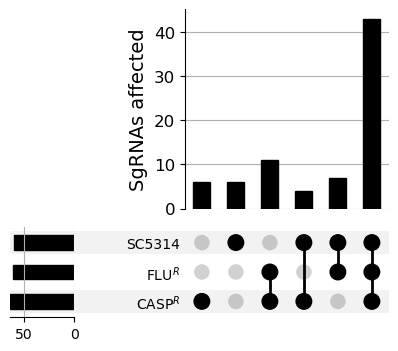

In [85]:
ax_dict = upsetplot.UpSet(snp_upset_df, subset_size="count").plot()
plt.ylabel('SgRNAs affected', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)


plt.savefig('./variants_effect_upset.svg', format='svg', dpi=300)

In [57]:
snp_to_sgrna_map

,sgRNA_ID,Chr,position,effect,fRS1,fRS242,fRS246,type,source,comment,Unnamed: 10
0,60,1,838214,True,het,het,B,SC5314_het,het_site_CGD,NaN,NaN
1,68,1,1166862,True,het,het,B,SC5314_het,het_site_CGD,NaN,NaN
2,83,1,1553473,True,het,het,het,SC5314_het,het_site_CGD,NaN,NaN
3,83,1,1553477,True,het,het,het,SC5314_het,het_site_CGD,NaN,NaN
4,85,1,1645351,True,A,A,A,SC5314_het,het_site_CGD,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
122,435,R,201954,True,hom,hom,alt,de_novo,fRS246_intersect,NaN,NaN
123,435,R,201957,True,hom,hom,alt,de_novo,fRS246_intersect,NaN,NaN
124,436,R,201943,True,hom,hom,alt,de_novo,fRS246_intersect,NaN,NaN
125,436,R,201954,True,hom,hom,alt,de_novo,fRS246_intersect,NaN,NaN
